In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [3]:
X.shape, y.shape

((20640, 8), (20640,))

In [4]:
X.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [5]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000


In [9]:
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

In [10]:
y.median()

1.797

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
le = LinearRegression()
le.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = le.predict(X_test)

In [14]:
def evaluate_model(y_true, y_pred):
    n = len(y_true)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R²': round(r2, 4),
    }
evaluate_model(y_test , y_pred)

{'MSE': 0.5559, 'RMSE': np.float64(0.7456), 'MAE': 0.5332, 'R²': 0.5758}

R^2 --> 0.57 It has moderate power. It is better than a simple average, but it still misses about 42.4% of the information.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
a = [0.01, 0.1, 1, 10, 100]
r2_scores_for_ridge = []
rmse_scores_ridge = []
for i in a:
    ridge = Ridge(alpha = i)
    ridge.fit(X_train_scaled, y_train)

    y_pred_ridge = ridge.predict(X_test_scaled)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2_ridge = r2_score(y_test, y_pred_ridge)
    rmse_scores_ridge.append(rmse_ridge)
    r2_scores_for_ridge.append(r2_ridge)
print('Ridge regression R2 score : ',r2_scores_for_ridge)
print('Ridge regression RMSE score: ',rmse_scores_ridge)

Ridge regression R2 score :  [0.57578798731216, 0.5757905180002314, 0.5758157428913684, 0.5760599032848372, 0.5777912763033605]
Ridge regression RMSE score:  [np.float64(0.7455811358288165), np.float64(0.7455789118982765), np.float64(0.7455567442814779), np.float64(0.7453421422218554), np.float64(0.7438185949703784)]


In [18]:
a = [0.01, 0.1, 1, 10, 100]
r2_scores_for_lasso = []
rmse_scores_lasso = []
for i in a:
    lasso = Lasso(alpha=i)
    lasso.fit(X_train_scaled, y_train)

    y_pred_lasso = lasso.predict(X_test_scaled)
    rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    r2_lasso = r2_score(y_test, y_pred_lasso)
    rmse_scores_lasso.append(rmse_lasso)
    r2_scores_for_lasso.append(r2_lasso)
print('Lasso regression R2 score : ',r2_scores_for_lasso)
print('Lasso regression RMSE score: ',rmse_scores_lasso)

Lasso regression R2 score :  [0.5816154300698727, 0.48136113250290735, -0.00021908714592466794, -0.00021908714592466794, -0.00021908714592466794]
Lasso regression RMSE score:  [np.float64(0.7404423656125414), np.float64(0.8243961598848472), np.float64(1.1448563543099792), np.float64(1.1448563543099792), np.float64(1.1448563543099792)]


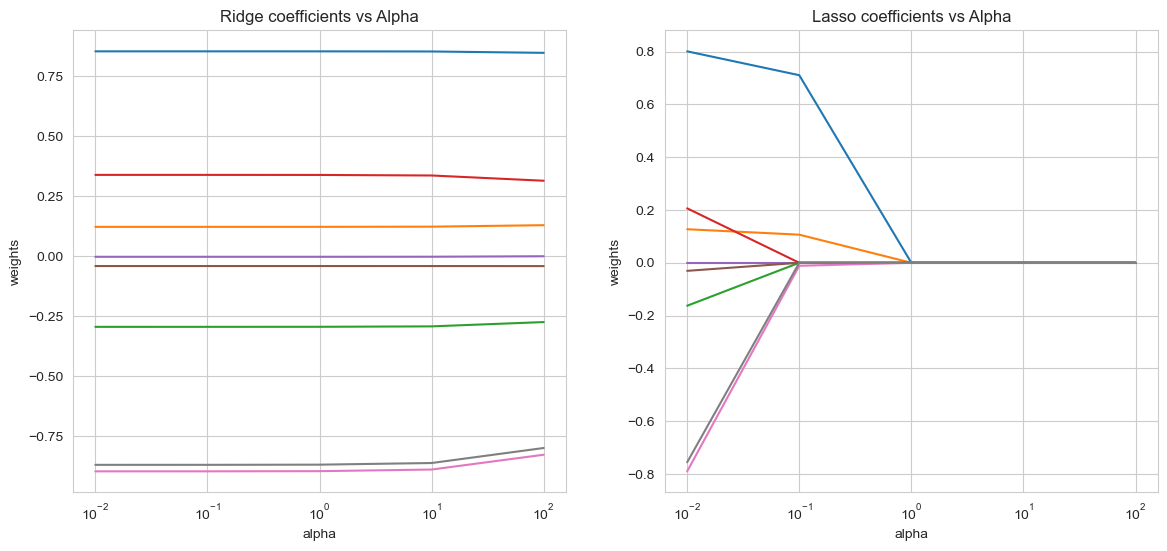

In [19]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.title('Ridge coefficients vs Alpha')
plt.xlabel('alpha')
plt.ylabel('weights')

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.title('Lasso coefficients vs Alpha')
plt.xlabel('alpha')
plt.ylabel('weights')

plt.show()

In [20]:
ols = LinearRegression().fit(X_train_scaled, y_train)
ols_r2 = ols.score(X_test_scaled, y_test)

best_ridge_r2 = max(r2_scores_for_ridge)
best_lasso_r2 = max(r2_scores_for_lasso) 

results = pd.DataFrame({
    'Model': ['OLS', 'Ridge (Best Alpha)', 'Lasso (Best Alpha)'],
    'R² Score': [ols_r2, best_ridge_r2, best_lasso_r2]
})

print(results)

                Model  R² Score
0                 OLS  0.575788
1  Ridge (Best Alpha)  0.577791
2  Lasso (Best Alpha)  0.581615


In [21]:
C_values = [0.1, 1, 10]
eps_values = [0.1, 0.2]
best_r2_rbf = -np.inf
best_params = {}

X_train_small = X_train_scaled[:5000]
y_train_small = y_train[:5000] 
print("RBF Kernel tuning:")
for c in C_values:
    for eps in eps_values:
        svr_rbf = SVR(kernel='rbf', C=c, epsilon=eps)
        svr_rbf.fit(X_train_small, y_train_small)
        score = svr_rbf.score(X_test_scaled, y_test)
        
        print(f"C={c}, epsilon={eps} -> R²: {score:.4f}")
        
        if score > best_r2_rbf:
            best_r2_rbf = score
            best_params = {'C': c, 'epsilon': eps}

print(f"\nBest RBF Params: {best_params} with R²: {best_r2_rbf:.4f}")

RBF Kernel tuning:
C=0.1, epsilon=0.1 -> R²: 0.6494
C=0.1, epsilon=0.2 -> R²: 0.6501
C=1, epsilon=0.1 -> R²: 0.7127
C=1, epsilon=0.2 -> R²: 0.7142
C=10, epsilon=0.1 -> R²: 0.7411
C=10, epsilon=0.2 -> R²: 0.7432

Best RBF Params: {'C': 10, 'epsilon': 0.2} with R²: 0.7432


In [22]:
for deg in [2, 3]:
    svr_poly = SVR(kernel='poly', degree=deg, C=1.0, epsilon=0.1)
    svr_poly.fit(X_train_small, y_train_small)
    poly_score = svr_poly.score(X_test_scaled, y_test)
    print(f"SVR Poly (degree={deg}) R²: {poly_score:.4f}")

SVR Poly (degree=2) R²: 0.1053
SVR Poly (degree=3) R²: 0.2204


SVR vs Linear Models: SVR with the RBF kernel is the best model. It reached an R^2 score of 0.7432 (using a subsample). This is much higher than Ridge and Lasso, which only reached about 0.58.Performance: The RBF kernel works well because it can find complex, non-linear patterns in the data. The Polynomial kernel (degree 2 and 3) was not successful, with much lower scores (0.10 and 0.22).

In [23]:
comparison_data = {
    'Model': ['Linear Regression (OLS)', 'Ridge (Best Alpha=100)', 'Lasso (Best Alpha=0.01)', 'SVR (Best RBF)'],
    'MSE': [0.5559, 0.5534, 0.5458, 0.3347], 
    'RMSE': [0.7456, 0.7439, 0.7388, 0.5785],
    'MAE': [0.5332, 0.5302, 0.5283, 0.4005],
    'R²': [0.5758, 0.5777, 0.5816, 0.7432]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df = comparison_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

print("Final Model Comparison:")
comparison_df

Final Model Comparison:


,Model,MSE,RMSE,MAE,R²
0,SVR (Best RBF),0.3347,0.5785,0.4005,0.7432
1,Lasso (Best Alpha=0.01),0.5458,0.7388,0.5283,0.5816
2,Ridge (Best Alpha=100),0.5534,0.7439,0.5302,0.5777
3,Linear Regression (OLS),0.5559,0.7456,0.5332,0.5758


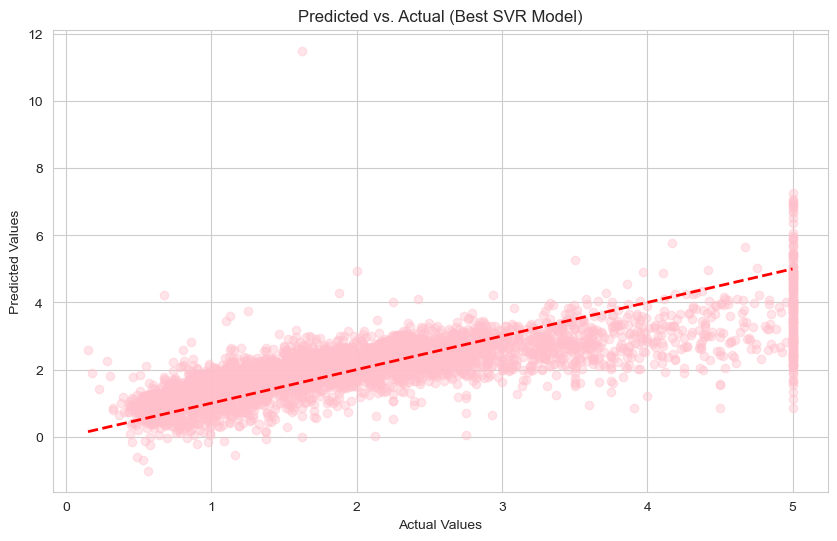

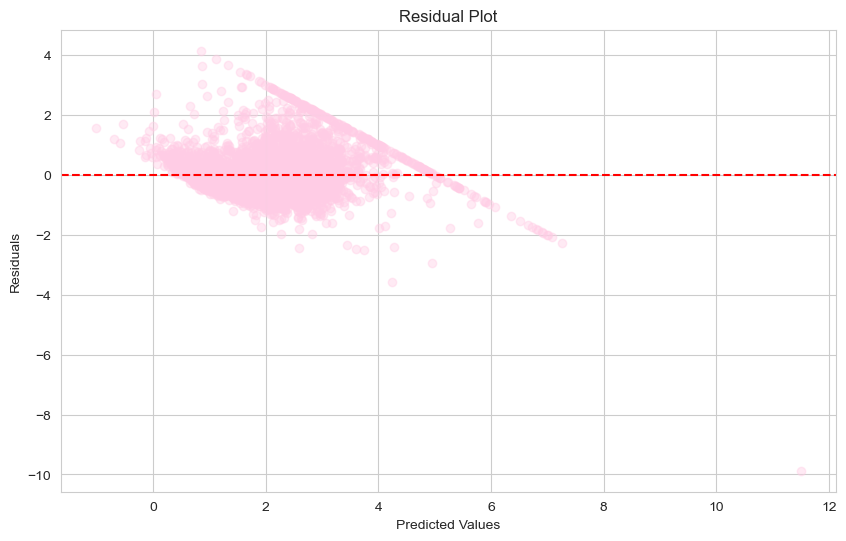

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='pink')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual (Best SVR Model)')
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.4, color='#FFCCE5')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

Predicted vs. Actual Plot  
Most points lie close to the red diagonal, indicating that the model’s predictions are generally accurate. The model tracks true values well, though there is some spread at higher price ranges, showing reduced accuracy for very expensive houses.

Residual Plot
The residuals are scattered randomly around the zero line, which is a positive sign—it suggests the model has captured the main data patterns, leaving only random noise. No clear “U” shape or trend is visible, confirming that the SVR with an RBF kernel is well-suited for this non-linear dataset.

Model Comparison  
The SVR (RBF kernel) outperforms Ridge and Lasso by effectively capturing non-linear relationships. While SVR is slower and more complex, its higher accuracy justifies the trade-off.

Deployment Choice  
For real estate pricing, accuracy outweighs speed. A 16% improvement in score translates to significantly better predictions, making SVR the preferred model for deployment